## 0) Variable meanings

This notebook predicts whether the center pixel will be burning one hour ahead using a GRU-based recurrent neural network that processes temporal sequences.

- **Prediction target**: center-cell GOES fire confidence at `t+1`, converted to binary.
- **Positive class (`1`)**: `confidence_t+1 >= POSITIVE_THRESHOLD`.
- **Negative class (`0`)**: `confidence_t+1 < POSITIVE_THRESHOLD`.
- **Temporal context**: `SEQ_LEN` consecutive hours of features ending at hour `t`.
- **Spatial context**: center + 8 neighbors (9-cell Moore neighborhood).
- **Per-cell features**: `fire_confidence`, `temperature`, `wind_speed`, `specific_humidity`, `precipitation_1h`, `discounted_rain_30d`, `wind_direction_sin`, `wind_direction_cos`.
- **Temporal derivatives**: hour-over-hour feature deltas appended at each timestep (doubles input dim to 144).
- **Model**: 2-layer GRU with Bahdanau (additive) attention, residual connection from last hidden state, and input projection.
- **Class imbalance techniques**:
  1. **Focal loss** (gamma=2.0, alpha=0.75): down-weights easy negatives.
  2. **Positive sequence cache**: accumulates fire-pixel sequences across chunks, injects cached positives into every batch.
  3. **Threshold optimization**: validation PR sweep selects best F1 threshold.
- **Training**: AdamW with warmup + cosine-decay LR schedule, gradient clipping, fire-order shuffling between epochs.
- **Evaluation**: fire-level holdout, per-fire metric breakdown, attention weight visualization.

In [1]:
from pathlib import Path

FIRE_SELECTION = "all"
TRAIN_FIRES = "auto"
TEST_FIRES = "auto"
FIRE_TRAIN_FRACTION = 0.70
FIRE_SPLIT_SEED = 42

POSITIVE_THRESHOLD = 0.10
CLASSIFICATION_PROB_THRESHOLD = 0.50
NORMALIZE_FEATURES = True
INCLUDE_DISCOUNTED_RAIN_FEATURE = True
DISCOUNTED_RAIN_LOOKBACK_HOURS = 24 * 30
DISCOUNTED_RAIN_HALF_LIFE_DAYS = 7.0

# RNN architecture
SEQ_LEN = 6
HIDDEN_DIM = 128
NUM_GRU_LAYERS = 2
DROPOUT = 0.3

# Temporal derivative features
INCLUDE_TEMPORAL_DELTAS = True

# Training
SEED = 1337
EPOCHS = 3
BATCH_SIZE = 4096
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 1.0
LR_WARMUP_FRACTION = 0.1

# Focal loss
FOCAL_ALPHA = 0.75
FOCAL_GAMMA = 2.0

# Positive sequence cache
POSITIVE_CACHE_MAX_SIZE = 50000
OVERSAMPLE_TARGET_POS_RATIO = 0.05

# Section toggles
RUN_FIRE_DISCOVERY_SECTION = True
RUN_DATA_STATS_SECTION = True
RUN_NORMALIZATION_SECTION = True
RUN_TRAINING_SECTION = True
RUN_EVALUATION_SECTION = True
RUN_PR_SECTION = True
RUN_REPORT_SECTION = True

In [2]:
print("fire selection:", FIRE_SELECTION)
print("positive threshold:", POSITIVE_THRESHOLD)
print("classification prob threshold:", CLASSIFICATION_PROB_THRESHOLD)
print("normalize features:", NORMALIZE_FEATURES)
print("include discounted rain:", INCLUDE_DISCOUNTED_RAIN_FEATURE)
print("include temporal deltas:", INCLUDE_TEMPORAL_DELTAS)
print()
print("RNN config:")
print("  seq_len:", SEQ_LEN)
print("  hidden_dim:", HIDDEN_DIM)
print("  num_gru_layers:", NUM_GRU_LAYERS)
print("  dropout:", DROPOUT)
print("  epochs:", EPOCHS)
print("  batch_size:", BATCH_SIZE)
print("  learning_rate:", LEARNING_RATE)
print("  lr_warmup_fraction:", LR_WARMUP_FRACTION)
print("  grad_clip_norm:", GRAD_CLIP_NORM)
print()
print("Class imbalance config:")
print("  focal_alpha:", FOCAL_ALPHA)
print("  focal_gamma:", FOCAL_GAMMA)
print("  oversample_target_pos_ratio:", OVERSAMPLE_TARGET_POS_RATIO)
print("  positive_cache_max_size:", POSITIVE_CACHE_MAX_SIZE)

fire selection: all
positive threshold: 0.1
classification prob threshold: 0.5
normalize features: True
include discounted rain: True
include temporal deltas: True

RNN config:
  seq_len: 6
  hidden_dim: 128
  num_gru_layers: 2
  dropout: 0.3
  epochs: 3
  batch_size: 4096
  learning_rate: 0.001
  lr_warmup_fraction: 0.1
  grad_clip_norm: 1.0

Class imbalance config:
  focal_alpha: 0.75
  focal_gamma: 2.0
  oversample_target_pos_ratio: 0.05
  positive_cache_max_size: 50000


In [3]:
import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

cwd = Path.cwd().resolve()
for candidate in [cwd] + list(cwd.parents):
    if (candidate / "scripts").exists() and (candidate / "docs").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError("Could not find repo root.")

from scripts.neighbor_cell_logreg import (
    build_feature_schema,
    collect_dataset_stats,
    discover_fire_entries,
    find_repo_root,
    fit_zscore_normalizer,
    iter_fire_hour_samples,
    safe_divide,
    select_fire_entries,
    split_fire_entries,
    split_validation_fire_entries,
)
from scripts.neighbor_cell_nn import pick_device

In [4]:
REPO_ROOT = find_repo_root(Path.cwd())
DEFAULT_DEVICE = pick_device()
print("repo root:", REPO_ROOT)
print("device:", DEFAULT_DEVICE)
print("torch:", torch.__version__)

repo root: /Users/seanmay/Desktop/Current Projects/wildfire-prediction
device: mps
torch: 2.5.1


## 1) Fire discovery and train/test split

Fire-level holdout: entire fires are assigned to train or test to prevent within-fire leakage.

In [5]:
all_fire_entries = []
fire_entries = []
train_fire_entries = []
test_fire_entries = []

if RUN_FIRE_DISCOVERY_SECTION:
    all_fire_entries = discover_fire_entries(REPO_ROOT)
    fire_entries = select_fire_entries(all_fire_entries, FIRE_SELECTION)
    train_fire_entries, test_fire_entries = split_fire_entries(
        fire_entries, TRAIN_FIRES, TEST_FIRES, FIRE_TRAIN_FRACTION, FIRE_SPLIT_SEED,
    )
    print("Train fires:", [e["fire_name"] for e in train_fire_entries])
    print("Test fires:", [e["fire_name"] for e in test_fire_entries])

Train fires: ['Antelope', 'Bobcat', 'Caldor', 'Creek', 'Dixie', 'Glass', 'July_Complex', 'KNP_Complex', 'Kincade', 'McFarland', 'Monument', 'North_Complex', 'Red_Salmon_Complex', 'River_Complex', 'SCU_Lightning_Complex', 'SQF_Complex', 'Slater_and_Devil', 'Tamarack', 'W-5_Cold_Springs', 'Zogg']
Test fires: ['August_Complex', 'Beckwourth_Complex', 'CZU_Lightning_Complex', 'Dolan', 'LNU_Lightning_Complex', 'McCash', 'Walker', 'Windy']


In [6]:
feature_schema = build_feature_schema(include_discounted_rain=INCLUDE_DISCOUNTED_RAIN_FEATURE)
N_FEATURES = feature_schema.n_features
RNN_INPUT_DIM = N_FEATURES * 2 if INCLUDE_TEMPORAL_DELTAS else N_FEATURES

print("features per timestep:", N_FEATURES)
print("RNN input dim (with deltas):", RNN_INPUT_DIM)
print("vars per cell:", feature_schema.var_order)

ITERATION_KWARGS = {
    "discounted_rain_lookback_hours": DISCOUNTED_RAIN_LOOKBACK_HOURS,
    "discounted_rain_half_life_days": DISCOUNTED_RAIN_HALF_LIFE_DAYS,
}

features per timestep: 72
RNN input dim (with deltas): 144
vars per cell: ['fire_confidence', 'temperature', 'wind_speed', 'specific_humidity', 'precipitation_1h', 'discounted_rain_30d', 'wind_direction_sin', 'wind_direction_cos']


## 2) Dataset statistics and normalization

Count samples and class balance, then fit z-score normalization on train-only data.

In [7]:
dataset_stats = None

if RUN_DATA_STATS_SECTION:
    dataset_stats = collect_dataset_stats(
        train_fire_entries, test_fire_entries, REPO_ROOT,
        feature_schema, POSITIVE_THRESHOLD, **ITERATION_KWARGS,
    )
    ts = dataset_stats["train"]
    es = dataset_stats["test"]
    print(f"Train: {ts['samples']:,} samples, {ts['positives']:,} pos ({dataset_stats['train_positive_rate']:.4%})")
    print(f"Test:  {es['samples']:,} samples, {es['positives']:,} pos ({dataset_stats['test_positive_rate']:.4%})")

Train: 99,990,857 samples, 307,246 pos (0.3073%)
Test:  43,895,169 samples, 125,969 pos (0.2870%)


In [8]:
normalizer = fit_zscore_normalizer(
    train_fire_entries, REPO_ROOT, feature_schema, POSITIVE_THRESHOLD,
    enabled=(RUN_NORMALIZATION_SECTION and NORMALIZE_FEATURES),
    **ITERATION_KWARGS,
)
print("normalization:", normalizer.method, "| samples:", normalizer.samples_used)

normalization: zscore_from_train_fires | samples: 99990857


## 3) GRU architecture

The model processes sequences of `SEQ_LEN` consecutive hours. Each timestep has 72 base features + 72 temporal deltas = 144 input dimensions.

**Architecture**:
1. **Input projection**: Linear(144 -> hidden_dim) with LayerNorm + ReLU.
2. **GRU encoder**: 2-layer GRU that captures temporal fire/weather dynamics.
3. **Bahdanau (additive) attention**: `V * tanh(W * h)` over GRU hidden states. More expressive than simple linear attention, learns nonlinear relevance scoring.
4. **Residual connection**: Last GRU hidden state concatenated with attention context, ensuring the most recent temporal state always has a direct path to the classifier.
5. **Classification head**: LayerNorm(hidden_dim*2) -> Linear -> ReLU -> Dropout -> Linear -> logit.

**Class imbalance**:
- **Focal loss**: With gamma=2.0, an easy negative (p=0.95 correct) has its loss reduced by ~400x vs standard cross-entropy.
- **Positive sequence cache**: Accumulates fire-pixel sequences across the fire, injects cached positives into every batch so even all-negative chunks get positive examples.

**Training**:
- **Fire-order shuffling**: Randomized fire processing order each epoch.
- **Warmup + cosine decay**: Linear LR warmup over first 10% of training, then cosine decay to near-zero.

In [9]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.V = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, gru_out):
        scores = self.V(torch.tanh(self.W(gru_out)))
        weights = F.softmax(scores, dim=1)
        context = (gru_out * weights).sum(dim=1)
        return context, weights.squeeze(-1)


class FireGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.attention = BahdanauAttention(hidden_dim)
        self.out_norm = nn.LayerNorm(hidden_dim * 2)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, return_attention=False):
        x = self.input_proj(x)
        gru_out, _ = self.gru(x)
        context, attn_weights = self.attention(gru_out)
        last_hidden = gru_out[:, -1, :]
        combined = self.out_norm(torch.cat([context, last_hidden], dim=1))
        logits = self.classifier(combined)
        if return_attention:
            return logits, attn_weights
        return logits


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p_t = torch.exp(-bce)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (alpha_t * (1 - p_t) ** self.gamma * bce).mean()


class WarmupCosineScheduler:
    def __init__(self, optimizer, warmup_steps, total_steps):
        self.optimizer = optimizer
        self.warmup_steps = max(warmup_steps, 1)
        self.total_steps = max(total_steps, warmup_steps + 1)
        self.base_lr = optimizer.param_groups[0]["lr"]
        self.step_count = 0

    def step(self):
        self.step_count += 1
        if self.step_count <= self.warmup_steps:
            lr = self.base_lr * self.step_count / self.warmup_steps
        else:
            progress = (self.step_count - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            lr = self.base_lr * 0.5 * (1 + np.cos(np.pi * min(progress, 1.0)))
        for pg in self.optimizer.param_groups:
            pg["lr"] = lr

    def get_lr(self):
        return self.optimizer.param_groups[0]["lr"]


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 4) Sequence construction, temporal deltas, and positive cache

Sequences are built by streaming through each fire's hourly samples with a rolling buffer. Only temporally contiguous hours (no gaps) form valid sequences.

**Temporal deltas**: At each timestep, hour-over-hour feature changes are computed and concatenated to the base features. The first timestep gets zero deltas. This gives the GRU explicit trend signals (rising temperature, shifting wind) without having to learn subtraction.

**Positive cache**: Unlike simple per-chunk oversampling (which is a no-op for chunks with zero fire pixels), the cache accumulates positive sequences across the entire fire and injects them into every batch. This ensures consistent positive exposure even for hours far from the fire front.

In [10]:
def add_temporal_deltas(X_seq):
    """Append hour-over-hour deltas at each timestep. First timestep gets zeros."""
    deltas = np.zeros_like(X_seq)
    deltas[:, 1:, :] = X_seq[:, 1:, :] - X_seq[:, :-1, :]
    return np.concatenate([X_seq, deltas], axis=-1)


class PositiveCache:
    """Accumulates positive sequences across chunks, injects into every batch."""

    def __init__(self, max_size=50000):
        self.max_size = max_size
        self.chunks = []
        self.total = 0

    def add(self, X_seq, y):
        pos_mask = y > 0.5
        if not pos_mask.any():
            return
        X_pos = X_seq[pos_mask].copy()
        self.chunks.append(X_pos)
        self.total += X_pos.shape[0]
        while self.total > self.max_size and len(self.chunks) > 1:
            removed = self.chunks.pop(0)
            self.total -= removed.shape[0]

    def inject(self, X_seq, y, target_ratio):
        if self.total == 0:
            return X_seq, y
        pos_mask = y > 0.5
        n_pos = int(pos_mask.sum())
        n_neg = int((~pos_mask).sum())
        if n_neg == 0:
            return X_seq, y
        n_target = int(target_ratio * n_neg / (1 - target_ratio))
        n_inject = max(0, n_target - n_pos)
        if n_inject == 0:
            return X_seq, y
        all_cached = np.concatenate(self.chunks, axis=0)
        idx = np.random.choice(all_cached.shape[0], size=min(n_inject, all_cached.shape[0] * 3), replace=True)
        X_inj = all_cached[idx]
        y_inj = np.ones(X_inj.shape[0], dtype=y.dtype)
        X_out = np.concatenate([X_seq, X_inj], axis=0)
        y_out = np.concatenate([y, y_inj], axis=0)
        perm = np.random.permutation(X_out.shape[0])
        return X_out[perm], y_out[perm]


def iter_fire_sequences(entry, repo_root, feature_schema, positive_threshold,
                        normalizer, seq_len, include_deltas=False, **kwargs):
    buffer = []
    for fire_name, t, X_hour, y_hour in iter_fire_hour_samples(
        entry, repo_root, feature_schema, positive_threshold, **kwargs,
    ):
        X_norm = normalizer.transform(X_hour).astype(np.float32, copy=False)
        y_bin = y_hour.astype(np.float32, copy=False)
        buffer.append((t, X_norm, y_bin))
        if len(buffer) > seq_len:
            buffer.pop(0)
        if len(buffer) == seq_len:
            t_vals = [b[0] for b in buffer]
            if t_vals[-1] - t_vals[0] != seq_len - 1:
                continue
            n_pix = buffer[0][1].shape[0]
            if not all(b[1].shape[0] == n_pix for b in buffer):
                continue
            X_seq = np.stack([b[1] for b in buffer], axis=1)
            if include_deltas:
                X_seq = add_temporal_deltas(X_seq)
            y = buffer[-1][2]
            yield X_seq, y

## 5) Training

- **Fire-order shuffling**: fires are randomly reordered each epoch to prevent ordering bias.
- **Positive cache**: builds up across each fire's chunks, injecting cached fire-pixel sequences into every batch.
- **LR schedule**: linear warmup for first 10% of steps, cosine decay for the rest.
- **Gradient clipping**: max norm=1.0 for RNN stability.

Training metrics are approximate due to positive injection; test metrics are exact.

In [11]:
set_seed(SEED)

model = FireGRU(RNN_INPUT_DIM, HIDDEN_DIM, NUM_GRU_LAYERS, DROPOUT).to(DEFAULT_DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)

estimated_seqs = dataset_stats["train"]["samples"] if dataset_stats else 50_000_000
estimated_steps = EPOCHS * (estimated_seqs // BATCH_SIZE)
warmup_steps = int(LR_WARMUP_FRACTION * estimated_steps)
scheduler = WarmupCosineScheduler(optimizer, warmup_steps, estimated_steps)

print(f"Parameters: {count_parameters(model):,}")
print(f"Architecture: FireGRU(input={RNN_INPUT_DIM}, hidden={HIDDEN_DIM}, layers={NUM_GRU_LAYERS})")
print(f"LR schedule: warmup {warmup_steps:,} steps, cosine decay over {estimated_steps:,} total steps")
print()

training_history = []

if RUN_TRAINING_SECTION:
    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_loss = 0.0
        epoch_batches = 0
        tp = fp = fn = tn = 0
        seq_count = 0
        pos_cache = PositiveCache(max_size=POSITIVE_CACHE_MAX_SIZE)

        epoch_entries = list(train_fire_entries)
        random.shuffle(epoch_entries)

        for entry in epoch_entries:
            for X_seq, y in iter_fire_sequences(
                entry, REPO_ROOT, feature_schema, POSITIVE_THRESHOLD,
                normalizer, SEQ_LEN, include_deltas=INCLUDE_TEMPORAL_DELTAS,
                **ITERATION_KWARGS,
            ):
                seq_count += X_seq.shape[0]
                pos_cache.add(X_seq, y)
                X_bat, y_bat = pos_cache.inject(X_seq, y, OVERSAMPLE_TARGET_POS_RATIO)

                for start in range(0, X_bat.shape[0], BATCH_SIZE):
                    end = min(X_bat.shape[0], start + BATCH_SIZE)
                    xb = torch.from_numpy(X_bat[start:end]).to(DEFAULT_DEVICE)
                    yb = torch.from_numpy(y_bat[start:end]).to(DEFAULT_DEVICE).unsqueeze(1)

                    optimizer.zero_grad(set_to_none=True)
                    logits = model(xb)
                    loss = criterion(logits, yb)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                    optimizer.step()
                    scheduler.step()

                    epoch_loss += loss.item()
                    epoch_batches += 1

                    with torch.no_grad():
                        pred = (torch.sigmoid(logits) >= CLASSIFICATION_PROB_THRESHOLD).int()
                        truth = yb.int()
                        tp += int(((pred == 1) & (truth == 1)).sum().cpu())
                        fp += int(((pred == 1) & (truth == 0)).sum().cpu())
                        fn += int(((pred == 0) & (truth == 1)).sum().cpu())
                        tn += int(((pred == 0) & (truth == 0)).sum().cpu())

        avg_loss = epoch_loss / max(epoch_batches, 1)
        total = tp + fp + fn + tn
        acc = (tp + tn) / max(total, 1)
        pos_acc = tp / max(tp + fn, 1)
        neg_acc = tn / max(tn + fp, 1)
        training_history.append({
            "epoch": epoch, "avg_loss": avg_loss, "accuracy": acc,
            "positive_accuracy": pos_acc, "negative_accuracy": neg_acc,
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "final_lr": scheduler.get_lr(), "cached_positives": pos_cache.total,
        })
        print(f"Epoch {epoch}/{EPOCHS}: loss={avg_loss:.4f} acc={acc:.4f} "
              f"pos_acc={pos_acc:.4f} neg_acc={neg_acc:.4f} lr={scheduler.get_lr():.2e} "
              f"cached_pos={pos_cache.total:,} seqs={seq_count:,}")

    pd.DataFrame(training_history)

Parameters: 250,497
Architecture: FireGRU(input=144, hidden=128, layers=2)
LR schedule: warmup 7,323 steps, cosine decay over 73,233 total steps

Epoch 1/3: loss=0.0051 acc=0.9908 pos_acc=0.9108 neg_acc=0.9950 lr=6.99e-04 cached_pos=49,995 seqs=99,309,722
Epoch 2/3: loss=0.0052 acc=0.9904 pos_acc=0.9087 neg_acc=0.9947 lr=5.43e-05 cached_pos=49,995 seqs=99,309,722
Epoch 3/3: loss=0.0060 acc=0.9894 pos_acc=0.9057 neg_acc=0.9938 lr=0.00e+00 cached_pos=49,932 seqs=99,309,722


## 6) Evaluation on held-out test fires

Evaluate at fixed classification threshold. No oversampling during evaluation.

In [12]:
def evaluate_rnn(model, entries, repo_root, feature_schema, positive_threshold,
                 normalizer, seq_len, include_deltas, prob_threshold, batch_size,
                 device, **kwargs):
    model.eval()
    tp = fp = fn = tn = 0
    n_eval = 0
    with torch.no_grad():
        for entry in entries:
            for X_seq, y in iter_fire_sequences(
                entry, repo_root, feature_schema, positive_threshold,
                normalizer, seq_len, include_deltas=include_deltas, **kwargs,
            ):
                for start in range(0, X_seq.shape[0], batch_size):
                    end = min(X_seq.shape[0], start + batch_size)
                    xb = torch.from_numpy(X_seq[start:end]).to(device)
                    yb = y[start:end].astype(np.int32)
                    logits = model(xb)
                    probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()
                    y_hat = (probs >= prob_threshold).astype(np.int32)
                    tp += int(((y_hat == 1) & (yb == 1)).sum())
                    fp += int(((y_hat == 1) & (yb == 0)).sum())
                    fn += int(((y_hat == 0) & (yb == 1)).sum())
                    tn += int(((y_hat == 0) & (yb == 0)).sum())
                    n_eval += int(yb.shape[0])
    return {
        "count": n_eval,
        "accuracy_overall": (tp + tn) / max(n_eval, 1),
        "positive_accuracy": tp / max(tp + fn, 1),
        "negative_accuracy": tn / max(tn + fp, 1),
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
    }


metrics_test = None

if RUN_EVALUATION_SECTION:
    metrics_test = evaluate_rnn(
        model, test_fire_entries, REPO_ROOT, feature_schema, POSITIVE_THRESHOLD,
        normalizer, SEQ_LEN, INCLUDE_TEMPORAL_DELTAS,
        CLASSIFICATION_PROB_THRESHOLD, BATCH_SIZE,
        DEFAULT_DEVICE, **ITERATION_KWARGS,
    )
    print(f"Test samples: {metrics_test['count']:,}")
    print(f"Overall accuracy: {metrics_test['accuracy_overall']:.4f}")
    print(f"Positive accuracy (recall): {metrics_test['positive_accuracy']:.4f}")
    print(f"Negative accuracy (specificity): {metrics_test['negative_accuracy']:.4f}")
    print(f"TP={metrics_test['tp']:,}  FP={metrics_test['fp']:,}  FN={metrics_test['fn']:,}  TN={metrics_test['tn']:,}")

Test samples: 43,641,779
Overall accuracy: 0.9937
Positive accuracy (recall): 0.8990
Negative accuracy (specificity): 0.9940
TP=113,123  FP=261,616  FN=12,703  TN=43,254,337


In [13]:
# Per-fire test breakdown: identify which fires the model handles well/poorly.

per_fire_results = []

if RUN_EVALUATION_SECTION and metrics_test is not None:
    print("Per-fire test metrics:")
    print(f"{'fire':>30s}  {'n':>10s}  {'prec':>6s}  {'rec':>6s}  {'f1':>6s}  {'TP':>7s}  {'FP':>7s}")
    print("-" * 85)

    for entry in test_fire_entries:
        fm = evaluate_rnn(
            model, [entry], REPO_ROOT, feature_schema, POSITIVE_THRESHOLD,
            normalizer, SEQ_LEN, INCLUDE_TEMPORAL_DELTAS,
            CLASSIFICATION_PROB_THRESHOLD, BATCH_SIZE,
            DEFAULT_DEVICE, **ITERATION_KWARGS,
        )
        fm["fire_name"] = entry["fire_name"]
        prec = fm["tp"] / max(fm["tp"] + fm["fp"], 1)
        rec = fm["tp"] / max(fm["tp"] + fm["fn"], 1)
        f1 = 2 * prec * rec / max(prec + rec, 1e-8)
        fm["precision"] = prec
        fm["recall"] = rec
        fm["f1"] = f1
        per_fire_results.append(fm)
        print(f"{entry['fire_name']:>30s}  {fm['count']:>10,}  {prec:>6.4f}  {rec:>6.4f}  {f1:>6.4f}  {fm['tp']:>7,}  {fm['fp']:>7,}")

    per_fire_df = pd.DataFrame(per_fire_results)
    per_fire_df

Per-fire test metrics:
                          fire           n    prec     rec      f1       TP       FP
-------------------------------------------------------------------------------------
                August_Complex  28,076,358  0.2933  0.8955  0.4419   58,890  141,889
            Beckwourth_Complex   2,395,380  0.3938  0.9180  0.5512    9,618   14,806
         CZU_Lightning_Complex     339,822  0.3514  0.9116  0.5073    2,186    4,035
                         Dolan   1,984,384  0.2442  0.8705  0.3814    7,005   21,685
         LNU_Lightning_Complex   4,336,400  0.3002  0.8965  0.4498   12,295   28,659
                        McCash   4,798,886  0.2591  0.8699  0.3993    9,472   27,083
                        Walker     546,210  0.3109  0.9029  0.4625    3,003    6,656
                         Windy   1,164,339  0.3880  0.9499  0.5510   10,654   16,803


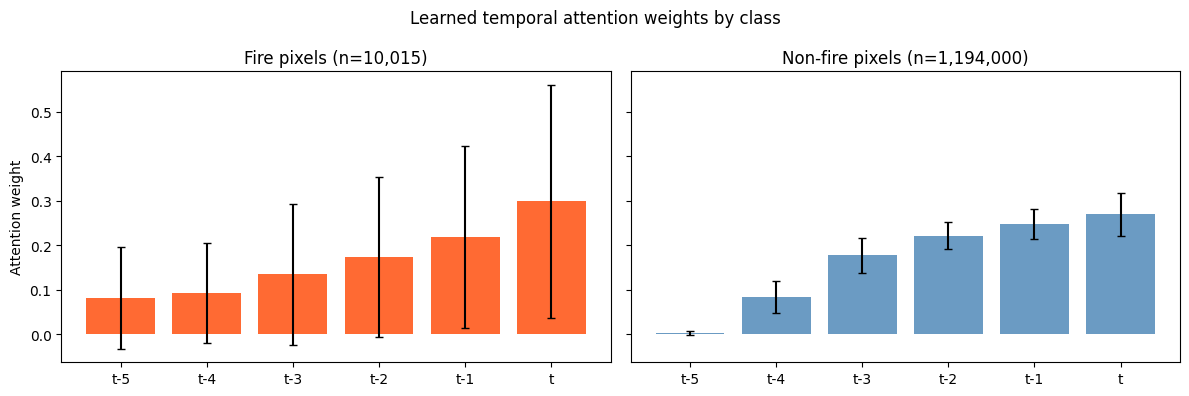

In [14]:
# Attention weight visualization: which hours does the model focus on?

if RUN_EVALUATION_SECTION:
    model.eval()
    all_pos_attn = []
    all_neg_attn = []

    with torch.no_grad():
        for entry in test_fire_entries[:3]:
            for X_seq, y in iter_fire_sequences(
                entry, REPO_ROOT, feature_schema, POSITIVE_THRESHOLD,
                normalizer, SEQ_LEN, include_deltas=INCLUDE_TEMPORAL_DELTAS,
                **ITERATION_KWARGS,
            ):
                n_sample = min(2000, X_seq.shape[0])
                xb = torch.from_numpy(X_seq[:n_sample]).to(DEFAULT_DEVICE)
                yb = y[:n_sample]
                _, attn_w = model(xb, return_attention=True)
                attn_np = attn_w.cpu().numpy()

                pos_mask = yb > 0.5
                if pos_mask.any():
                    all_pos_attn.append(attn_np[pos_mask])
                if (~pos_mask).any():
                    all_neg_attn.append(attn_np[~pos_mask][:500])

                if sum(a.shape[0] for a in all_pos_attn) > 10000:
                    break
            if sum(a.shape[0] for a in all_pos_attn) > 10000:
                break

    hours_ago = list(range(SEQ_LEN - 1, -1, -1))
    hour_labels = [f"t-{h}" if h > 0 else "t" for h in hours_ago]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    if all_pos_attn:
        pos_attn = np.concatenate(all_pos_attn, axis=0)
        axes[0].bar(range(SEQ_LEN), pos_attn.mean(axis=0),
                    yerr=pos_attn.std(axis=0), capsize=3, color="orangered", alpha=0.8)
        axes[0].set_xticks(range(SEQ_LEN))
        axes[0].set_xticklabels(hour_labels)
        axes[0].set_title(f"Fire pixels (n={pos_attn.shape[0]:,})")
        axes[0].set_ylabel("Attention weight")

    if all_neg_attn:
        neg_attn = np.concatenate(all_neg_attn, axis=0)
        axes[1].bar(range(SEQ_LEN), neg_attn.mean(axis=0),
                    yerr=neg_attn.std(axis=0), capsize=3, color="steelblue", alpha=0.8)
        axes[1].set_xticks(range(SEQ_LEN))
        axes[1].set_xticklabels(hour_labels)
        axes[1].set_title(f"Non-fire pixels (n={neg_attn.shape[0]:,})")

    fig.suptitle("Learned temporal attention weights by class")
    fig.tight_layout()
    plt.show()

## 7) Precision-recall analysis

1. Train a temporary GRU on inner-train fires, sweep thresholds on validation fires, select best F1 threshold.
2. Transfer selected threshold to main model on test fires.
3. Sweep full test PR curve with main model.

In [15]:
def compute_rnn_pr_curve(model, entries, repo_root, feature_schema, positive_threshold,
                        normalizer, seq_len, include_deltas, thresholds, batch_size,
                        device, **kwargs):
    model.eval()
    tp_arr = np.zeros(len(thresholds), dtype=np.int64)
    fp_arr = np.zeros(len(thresholds), dtype=np.int64)
    total_pos = 0
    total_neg = 0
    with torch.no_grad():
        for entry in entries:
            for X_seq, y in iter_fire_sequences(
                entry, repo_root, feature_schema, positive_threshold,
                normalizer, seq_len, include_deltas=include_deltas, **kwargs,
            ):
                for start in range(0, X_seq.shape[0], batch_size):
                    end = min(X_seq.shape[0], start + batch_size)
                    xb = torch.from_numpy(X_seq[start:end]).to(device)
                    yb = y[start:end].astype(np.int32)
                    logits = model(xb)
                    probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()
                    pos = yb == 1
                    total_pos += int(pos.sum())
                    total_neg += int((~pos).sum())
                    pred = probs[:, None] >= thresholds[None, :]
                    tp_arr += (pred & pos[:, None]).sum(axis=0).astype(np.int64)
                    fp_arr += (pred & (~pos)[:, None]).sum(axis=0).astype(np.int64)
    fn_arr = total_pos - tp_arr
    precision = safe_divide(tp_arr, tp_arr + fp_arr, default=1.0)
    recall = safe_divide(tp_arr, np.full_like(tp_arr, total_pos), default=0.0)
    f1 = safe_divide(2.0 * precision * recall, precision + recall, default=0.0)
    df = pd.DataFrame({
        "threshold": thresholds, "precision": precision, "recall": recall,
        "f1": f1, "tp": tp_arr, "fp": fp_arr, "fn": fn_arr,
        "tn": total_neg - fp_arr,
    })
    best = df.iloc[int(df["f1"].idxmax())]
    baseline = total_pos / max(total_pos + total_neg, 1)
    return {"df": df, "best": best, "baseline": baseline}

inner-train fires: ['Antelope', 'Bobcat', 'Creek', 'Glass', 'July_Complex', 'Kincade', 'McFarland', 'Monument', 'Red_Salmon_Complex', 'River_Complex', 'SCU_Lightning_Complex', 'Slater_and_Devil', 'W-5_Cold_Springs', 'Zogg']
validation fires: ['Caldor', 'Dixie', 'KNP_Complex', 'North_Complex', 'SQF_Complex', 'Tamarack']
Training validation model...
  val model epoch 1/3 done
  val model epoch 2/3 done
  val model epoch 3/3 done

Best val threshold: 0.948
  precision=0.7528 recall=0.7405 f1=0.7466


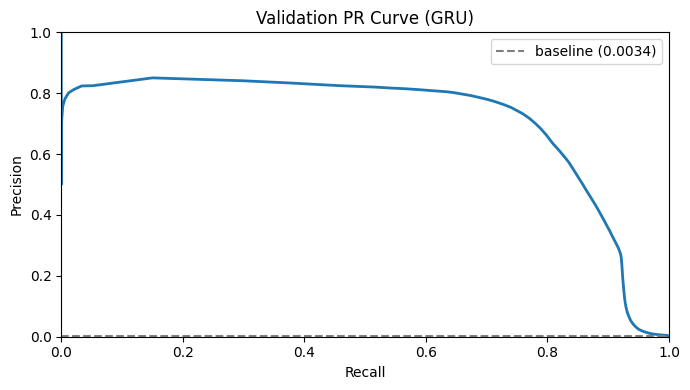

In [16]:
VAL_PR_THRESHOLDS = np.linspace(0.0, 1.0, 1001)
VAL_TUNED_THRESHOLD = None
val_pr_df = None
val_best = None
val_entries = []

if RUN_PR_SECTION:
    inner_train_entries, val_entries = split_validation_fire_entries(
        train_fire_entries, "auto", 0.30, 123,
    )
    print("inner-train fires:", [e["fire_name"] for e in inner_train_entries])
    print("validation fires:", [e["fire_name"] for e in val_entries])

    val_normalizer = fit_zscore_normalizer(
        inner_train_entries, REPO_ROOT, feature_schema, POSITIVE_THRESHOLD,
        enabled=NORMALIZE_FEATURES, **ITERATION_KWARGS,
    )

    set_seed(SEED)
    val_model = FireGRU(RNN_INPUT_DIM, HIDDEN_DIM, NUM_GRU_LAYERS, DROPOUT).to(DEFAULT_DEVICE)
    val_optimizer = torch.optim.AdamW(val_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    val_criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)

    val_est_steps = EPOCHS * (dataset_stats["train"]["samples"] // BATCH_SIZE) if dataset_stats else 30000
    val_scheduler = WarmupCosineScheduler(val_optimizer, int(LR_WARMUP_FRACTION * val_est_steps), val_est_steps)

    print("Training validation model...")
    for epoch in range(1, EPOCHS + 1):
        val_model.train()
        val_cache = PositiveCache(max_size=POSITIVE_CACHE_MAX_SIZE)
        val_epoch_entries = list(inner_train_entries)
        random.shuffle(val_epoch_entries)

        for entry in val_epoch_entries:
            for X_seq, y in iter_fire_sequences(
                entry, REPO_ROOT, feature_schema, POSITIVE_THRESHOLD,
                val_normalizer, SEQ_LEN, include_deltas=INCLUDE_TEMPORAL_DELTAS,
                **ITERATION_KWARGS,
            ):
                val_cache.add(X_seq, y)
                X_bat, y_bat = val_cache.inject(X_seq, y, OVERSAMPLE_TARGET_POS_RATIO)
                for start in range(0, X_bat.shape[0], BATCH_SIZE):
                    end = min(X_bat.shape[0], start + BATCH_SIZE)
                    xb = torch.from_numpy(X_bat[start:end]).to(DEFAULT_DEVICE)
                    yb = torch.from_numpy(y_bat[start:end]).to(DEFAULT_DEVICE).unsqueeze(1)
                    val_optimizer.zero_grad(set_to_none=True)
                    logits = val_model(xb)
                    loss = val_criterion(logits, yb)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(val_model.parameters(), GRAD_CLIP_NORM)
                    val_optimizer.step()
                    val_scheduler.step()
        print(f"  val model epoch {epoch}/{EPOCHS} done")

    val_pr_result = compute_rnn_pr_curve(
        val_model, val_entries, REPO_ROOT, feature_schema, POSITIVE_THRESHOLD,
        val_normalizer, SEQ_LEN, INCLUDE_TEMPORAL_DELTAS,
        VAL_PR_THRESHOLDS, BATCH_SIZE, DEFAULT_DEVICE,
        **ITERATION_KWARGS,
    )
    val_pr_df = val_pr_result["df"]
    val_best = val_pr_result["best"].to_dict()
    VAL_TUNED_THRESHOLD = float(val_pr_result["best"]["threshold"])

    print(f"\nBest val threshold: {VAL_TUNED_THRESHOLD:.3f}")
    print(f"  precision={val_best['precision']:.4f} recall={val_best['recall']:.4f} f1={val_best['f1']:.4f}")

    fig, ax = plt.subplots(figsize=(7, 4))
    plot_df = val_pr_df.sort_values("recall")
    ax.plot(plot_df["recall"], plot_df["precision"], linewidth=2)
    ax.axhline(val_pr_result["baseline"], ls="--", color="gray",
               label=f"baseline ({val_pr_result['baseline']:.4f})")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("Validation PR Curve (GRU)")
    ax.legend(); fig.tight_layout(); plt.show()

Val threshold (0.948) on test: prec=0.0000 rec=0.0000 f1=0.0000

Best test threshold: 0.774
  precision=0.7579 recall=0.7389 f1=0.7483


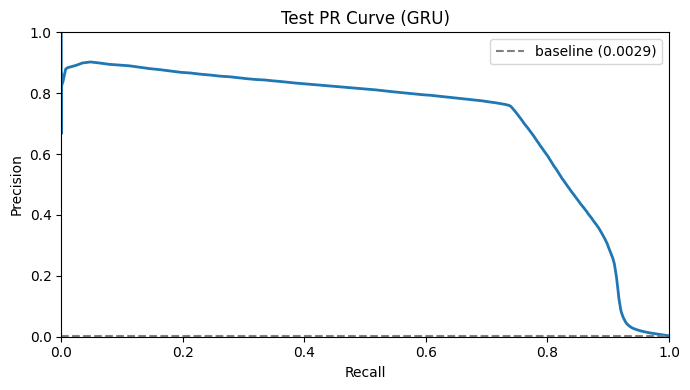

In [17]:
train_threshold_test_metrics = None
test_pr_df = None
test_pr_best = None
test_pr_baseline = None

if RUN_PR_SECTION:
    if VAL_TUNED_THRESHOLD is not None:
        train_threshold_test_metrics = evaluate_rnn(
            model, test_fire_entries, REPO_ROOT, feature_schema, POSITIVE_THRESHOLD,
            normalizer, SEQ_LEN, INCLUDE_TEMPORAL_DELTAS,
            VAL_TUNED_THRESHOLD, BATCH_SIZE, DEFAULT_DEVICE,
            **ITERATION_KWARGS,
        )
        m = train_threshold_test_metrics
        prec = m["tp"] / max(m["tp"] + m["fp"], 1)
        rec = m["tp"] / max(m["tp"] + m["fn"], 1)
        f1_val = 2 * prec * rec / max(prec + rec, 1e-8)
        print(f"Val threshold ({VAL_TUNED_THRESHOLD:.3f}) on test: prec={prec:.4f} rec={rec:.4f} f1={f1_val:.4f}")

    TEST_PR_THRESHOLDS = np.linspace(0.0, 1.0, 1001)
    test_pr_result = compute_rnn_pr_curve(
        model, test_fire_entries, REPO_ROOT, feature_schema, POSITIVE_THRESHOLD,
        normalizer, SEQ_LEN, INCLUDE_TEMPORAL_DELTAS,
        TEST_PR_THRESHOLDS, BATCH_SIZE, DEFAULT_DEVICE,
        **ITERATION_KWARGS,
    )
    test_pr_df = test_pr_result["df"]
    test_pr_best = test_pr_result["best"].to_dict()
    test_pr_baseline = float(test_pr_result["baseline"])

    print(f"\nBest test threshold: {test_pr_best['threshold']:.3f}")
    print(f"  precision={test_pr_best['precision']:.4f} recall={test_pr_best['recall']:.4f} f1={test_pr_best['f1']:.4f}")

    fig, ax = plt.subplots(figsize=(7, 4))
    plot_df = test_pr_df.sort_values("recall")
    ax.plot(plot_df["recall"], plot_df["precision"], linewidth=2)
    ax.axhline(test_pr_baseline, ls="--", color="gray",
               label=f"baseline ({test_pr_baseline:.4f})")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("Test PR Curve (GRU)")
    ax.legend(); fig.tight_layout(); plt.show()

In [18]:
if test_pr_df is not None:
    test_pr_df.sort_values("f1", ascending=False).head(20)

## 8) Report

Save configuration, architecture, and evaluation metrics to JSON.

In [19]:
def to_json_safe(obj):
    if isinstance(obj, dict):
        return {k: to_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_json_safe(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, pd.Series):
        return to_json_safe(obj.to_dict())
    return obj


if RUN_REPORT_SECTION:
    report = {
        "model": "gru_temporal_attention",
        "target": "center_confidence_t_plus_1_binary",
        "fires_used": [e["fire_name"] for e in fire_entries],
        "train_fires": [e["fire_name"] for e in train_fire_entries],
        "test_fires": [e["fire_name"] for e in test_fire_entries],
        "validation_fires": [e["fire_name"] for e in val_entries],
        "thresholds": {
            "positive_confidence": POSITIVE_THRESHOLD,
            "classification_probability": CLASSIFICATION_PROB_THRESHOLD,
            "validation_selected_probability": VAL_TUNED_THRESHOLD,
        },
        "split": {
            "method": "fire_holdout",
            "train_fire_count": len(train_fire_entries),
            "test_fire_count": len(test_fire_entries),
            "train_fire_fraction_target": FIRE_TRAIN_FRACTION,
            "split_seed": FIRE_SPLIT_SEED,
        },
        "architecture": {
            "type": "GRU_with_bahdanau_attention_and_residual",
            "seq_len": SEQ_LEN,
            "input_dim": RNN_INPUT_DIM,
            "base_features": N_FEATURES,
            "include_temporal_deltas": INCLUDE_TEMPORAL_DELTAS,
            "hidden_dim": HIDDEN_DIM,
            "num_gru_layers": NUM_GRU_LAYERS,
            "dropout": DROPOUT,
            "parameter_count": count_parameters(model),
        },
        "class_imbalance": {
            "focal_loss_alpha": FOCAL_ALPHA,
            "focal_loss_gamma": FOCAL_GAMMA,
            "oversample_target_pos_ratio": OVERSAMPLE_TARGET_POS_RATIO,
            "positive_cache_max_size": POSITIVE_CACHE_MAX_SIZE,
        },
        "training": {
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "grad_clip_norm": GRAD_CLIP_NORM,
            "lr_warmup_fraction": LR_WARMUP_FRACTION,
            "seed": SEED,
            "device": str(DEFAULT_DEVICE),
            "history": training_history,
        },
        "metrics_test_fixed_threshold": {
            "threshold": CLASSIFICATION_PROB_THRESHOLD,
            **(metrics_test if metrics_test else {}),
        },
        "per_fire_test_metrics": per_fire_results if per_fire_results else [],
        "validation_threshold_selection": {
            "best_threshold": VAL_TUNED_THRESHOLD,
            "best_metrics": val_best,
        },
        "train_threshold_transfer": train_threshold_test_metrics,
        "test_pr_curve": {
            "baseline": test_pr_baseline,
            "best": test_pr_best,
            "top_by_f1": (
                test_pr_df.sort_values("f1", ascending=False)
                .head(12).to_dict(orient="records")
                if test_pr_df is not None else []
            ),
        },
        "feature_order": feature_schema.feature_names,
        "data": {
            "total_samples": int(dataset_stats["total_samples"]) if dataset_stats else 0,
            "train_samples": int(dataset_stats["train"]["samples"]) if dataset_stats else 0,
            "test_samples": int(dataset_stats["test"]["samples"]) if dataset_stats else 0,
        },
    }

    report = to_json_safe(report)
    out_dir = REPO_ROOT / "data" / "analysis" / "rnn_fire_holdout"
    out_dir.mkdir(parents=True, exist_ok=True)
    report_path = out_dir / "report.json"
    with report_path.open("w", encoding="utf-8") as f:
        json.dump(report, f, indent=2)
    print("saved:", report_path)
    print("Report keys:", list(report.keys()))

saved: /Users/seanmay/Desktop/Current Projects/wildfire-prediction/data/analysis/rnn_fire_holdout/report.json
Report keys: ['model', 'target', 'fires_used', 'train_fires', 'test_fires', 'validation_fires', 'thresholds', 'split', 'architecture', 'class_imbalance', 'training', 'metrics_test_fixed_threshold', 'per_fire_test_metrics', 'validation_threshold_selection', 'train_threshold_transfer', 'test_pr_curve', 'feature_order', 'data']


## 9) Notes

- **Temporal deltas**: Hour-over-hour feature changes (temperature delta, wind speed delta, etc.) are concatenated at each timestep, doubling input dim from 72 to 144. The first timestep gets zero deltas. This gives the GRU explicit trend signals without having to learn subtraction.
- **Bahdanau attention**: Uses `V * tanh(W * h)` scoring instead of simple linear projection. The tanh nonlinearity allows learning more complex relevance patterns across timesteps.
- **Residual connection**: Last GRU hidden state is concatenated with the attention-weighted context before classification. This ensures the most recent temporal state always has a direct gradient path, preventing information loss through attention averaging.
- **Positive sequence cache**: Unlike simple per-chunk oversampling (which is a no-op for chunks with zero fire pixels—the vast majority), the cache accumulates fire-pixel sequences and injects them into every batch. This ensures consistent positive exposure throughout training.
- **Fire-order shuffling**: Fires are randomly reordered each epoch to prevent the model from learning ordering-dependent biases.
- **Warmup + cosine decay**: Linear LR warmup for the first 10% of training steps stabilizes early RNN gradients, followed by cosine decay for smooth convergence.
- **Per-fire evaluation**: The metric breakdown by fire reveals whether the model generalizes across fire types or overfits to patterns from specific (often larger) fires.
- **Attention visualization**: Comparing learned attention weights between fire and non-fire pixels reveals which historical hours the model relies on most for each class.
- **Gradient clipping** (max norm=1.0) prevents exploding gradients common in RNN training.
- Adjust `SEQ_LEN` to explore other temporal window sizes. Longer windows capture more context but increase memory and training time.